# HW_4 Spectrogram. Roman Branovets, Skoltech, 2025

In [3]:
import numpy as np
from numpy import fft
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import time
from math import pi, exp

1. Add 4th wave packet (frequency = 4 and time_shift = 7 cycles). Demonstrate the effect on the plot of the FFT spectrum

Text(0, 0.5, 'signal, arb.units')

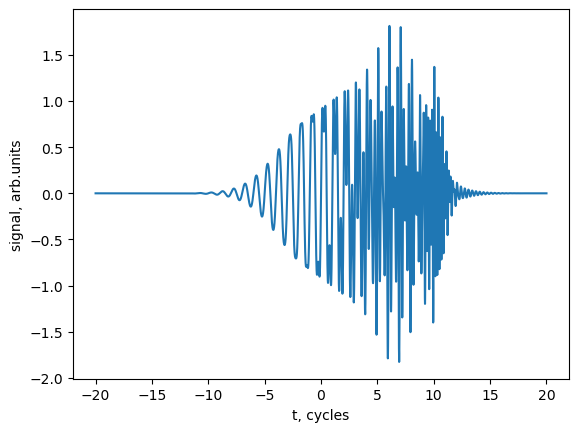

In [4]:
# generate the signal
nofts=1000
t=np.linspace(-20*2*np.pi, 20*2*np.pi, 2**14+5)
t=np.linspace(-20*2*np.pi, 20*2*np.pi, 3**9+6)
y=np.sin(t)*np.exp(-t**2/2/20**2)
y=y+np.sin(3*t)*np.exp(-(t-5*2*np.pi)**2/2/20**2)
y=y+np.sin(5.5*t)*np.exp(-(t-10*2*np.pi)**2/2/5**2)
y = y + np.sin(4*t)*np.exp(-(t - 7*2*np.pi)**2/2/10**2)

plt.plot(t/2/pi,y)

plt.xlabel('t, cycles')
plt.ylabel('signal, arb.units')

Text(0, 0.5, 'Power spectrum, arb. units')

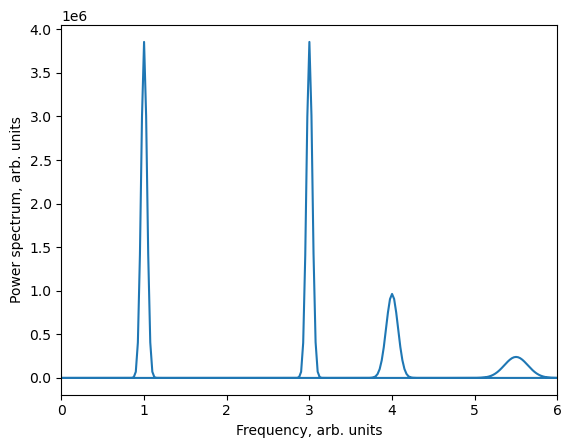

In [5]:
# Fourier spectrum
sp=fft(y)
w=fftfreq(len(y), d=(t[1]-t[0])/2/pi)
plt.plot(w, abs(sp)**2)
plt.xlim(0,6)
plt.xlabel('Frequency, arb. units')
plt.ylabel('Power spectrum, arb. units')

Effect : A new peak at frequency 4 in the power spectrum, which increases the total energy

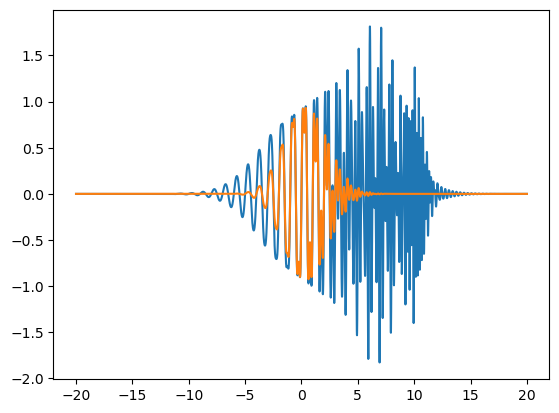

In [6]:
# windowed Fourier transform (Gabor transform, spectrogram)

window_width=2.0*2*np.pi
window_position=0.0*2*np.pi
window_function=np.exp(-(t-window_position)**2/2/window_width**2)

y_window=y * window_function

plt.plot(t/2/pi, y)
plt.plot(t/2/pi, y_window)

# now do the same for different window positions and plot 2D graph
# x_axis is window position
# y_axis is frequency
# color axis represents the power spectrum

2. Implement the spectrogram, show the effect of (1) on the spectrogram

In [7]:
def get_specgram(y, t, nwindowsteps=1000):
    window_width = 2.0 * 2 * np.pi
    t_window_positions = np.linspace(t[0], t[-1], nwindowsteps)
    specgram = np.empty((len(t), len(t_window_positions)))
    for i, pos in enumerate(t_window_positions):
        window_function = np.exp(-(t - pos)**2 / (2 * window_width**2))
        y_window = y * window_function
        specgram[:, i] = np.abs(fft(y_window))
    half_N = len(t) // 2
    specgram = specgram[:half_N, :]
    freqs = fftfreq(len(t), d=(t[1] - t[0]) / (2*np.pi))[:half_N]
    time_pos = t_window_positions / (2*np.pi)
    return specgram, time_pos, freqs

(0.0, 6.5)

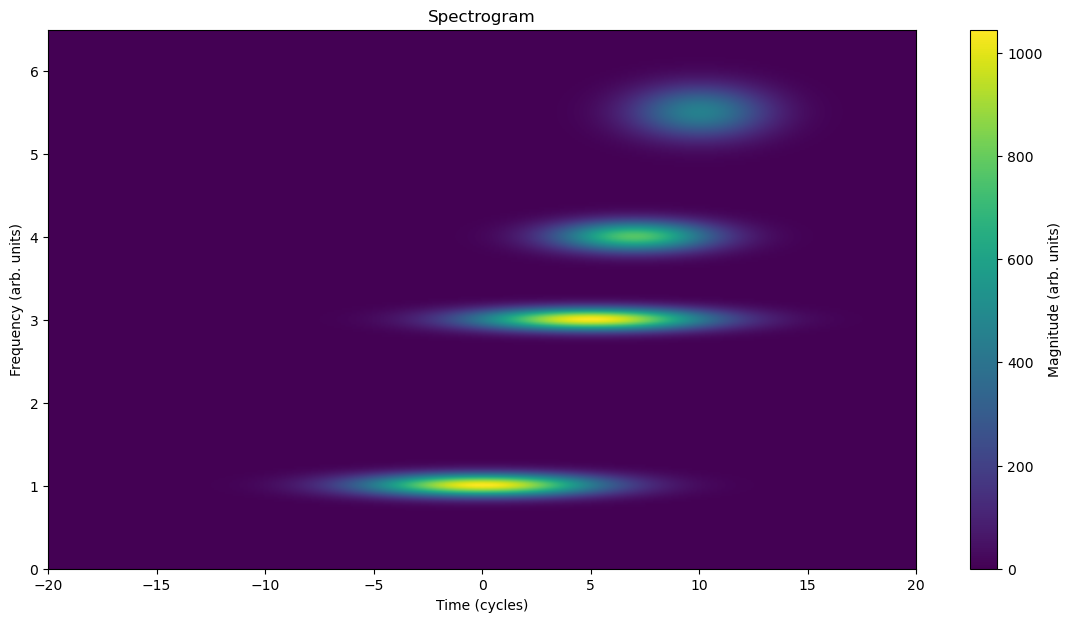

In [8]:
S, time_pos, freqs = get_specgram(y, t)
plt.figure(figsize=(14, 7))
extent = [time_pos[0], time_pos[-1], freqs[0], freqs[-1]]
im = plt.imshow(S, aspect='auto', origin='lower', extent=extent, cmap='viridis', interpolation='bilinear')
plt.xlabel('Time (cycles)')
plt.ylabel('Frequency (arb. units)')
plt.title('Spectrogram')
plt.colorbar(im, label='Magnitude (arb. units)')
plt.ylim(0, 6.5)

We see that a new spot has appeared on the spectrogram, shifted in time by 7 at frequency 4 due to the addition of a new wave packet. Its amplitude is smaller than that of the first two spots due to the smaller Gaussian.

3. Change the number of time steps in your signal to the power of 2 (i.e. 2^14) and then slightly change the number of timesteps (i.e 2^14 +- 5). Measure the timing, can you explain the difference? Write something as a possible explanation.

In [9]:
def time_fft(points):
    n = 1000
    t = np.linspace(-20*2*np.pi, 20*2*np.pi, points)
    y=np.sin(t)*np.exp(-t**2/2/20**2)
    y=y+np.sin(3*t)*np.exp(-(t-5*2*np.pi)**2/2/20**2)
    y=y+np.sin(5.5*t)*np.exp(-(t-10*2*np.pi)**2/2/5**2)
    y = y + np.sin(4*t)*np.exp(-(t - 7*2*np.pi)**2/2/10**2)
    times = []
    for i in range(n):
        start = time.time()
        sp = fft(y)
        w=fftfreq(len(y), d=(t[1]-t[0])/2/pi)
        end = time.time()
        times.append(end - start)
    return np.mean(times)

In [10]:
for i in range(2**14-5, 2**14+6):
    timing = time_fft(i)
    print(f'For {i} timesteps: {timing*1000} ms')

For 16379 timesteps: 2.330601215362549 ms
For 16380 timesteps: 0.40556788444519043 ms
For 16381 timesteps: 2.3108103275299072 ms
For 16382 timesteps: 2.316660165786743 ms
For 16383 timesteps: 1.0220849514007568 ms
For 16384 timesteps: 0.27754950523376465 ms
For 16385 timesteps: 0.8964109420776367 ms
For 16386 timesteps: 1.5269513130187988 ms
For 16387 timesteps: 1.5169463157653809 ms
For 16388 timesteps: 1.5488402843475342 ms
For 16389 timesteps: 1.4562876224517822 ms


As we can see, the FFT performs O(N log N) complexity optimally only when N is a power of 2. For other sizes, significant overhead is introduced. I think it is related with power of 2 sizes align better with computer memory architecture and also how fft algorithm is organized.